# Chapter 19: Numerical Integration Is Part of the Model

*Systems Thinking with AI* by Jason Karpeles

The same equations give different answers under different solvers, steps and update orders.

**Goal.** Four small experiments on the chapter's growth model with a rate of 2.6 and a capacity of 100. Change the solver and the step, see what Euler assumes, break conservation with the wrong update order, and apply the three-run refinement test with a tolerance.

**Demonstrations**

1. Three answers from one model
2. What Euler assumes about the rate
3. Sequential update is a different model
4. The refinement test

The chapter's own model code is written out in full below, so the notebook runs with NumPy and Matplotlib alone. The interactive version of this chapter is at [https://karpeles.com/companions/systems-thinking-with-ai/19-integration/reader.html](https://karpeles.com/companions/systems-thinking-with-ai/19-integration/reader.html).

All example inputs are constructed teaching examples built from the chapter's own numbers.

## Setup

Imports, plus two small helpers: `%%module` runs a cell as a named module so the chapter files can import one another by their package names, and `show` draws a demonstration's figure and lists its values.

In [1]:
import os, sys, tempfile, types
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from IPython.core.magic import register_cell_magic
from IPython.display import Markdown, display

%matplotlib inline

WORKDIR = tempfile.mkdtemp(prefix="systems-thinking-")


@register_cell_magic
def module(line, cell):
    """Run a cell as a named module so the chapter code can import it by name."""
    name = line.strip()
    parts = name.split(".")
    for i in range(1, len(parts)):
        parent = ".".join(parts[:i])
        if parent not in sys.modules:
            pkg = types.ModuleType(parent)
            pkg.__path__ = []
            sys.modules[parent] = pkg
            if i > 1:
                setattr(sys.modules[".".join(parts[:i - 1])], parts[i - 1], pkg)
    mod = types.ModuleType(name)
    mod.__file__ = os.path.join(WORKDIR, *parts) + ".py"
    mod.__package__ = ".".join(parts[:-1])
    sys.modules[name] = mod
    if len(parts) > 1:
        setattr(sys.modules[".".join(parts[:-1])], parts[-1], mod)
    exec(compile(cell, name, "exec"), mod.__dict__)


def show(result):
    """Draw the figure, then list the calculated values and the reading."""
    fig, metrics, interpretation = result[:3]
    plt.show()
    display(Markdown("\n".join(f"- **{k}:** {v}" for k, v in metrics.items())))
    display(Markdown(interpretation))


def sweep(function, controls):
    """Recompute every setting offered in the interactive reader and list the values."""
    import itertools
    keys = [k for k, _ in controls]
    rows = []
    for combo in itertools.product(*[v for _, v in controls]):
        fig, metrics, _ = function(**dict(zip(keys, combo)))[:3]
        plt.close(fig)
        setting = ", ".join(f"{k} = {v}" for k, v in zip(keys, combo))
        rows.append(f"- **{setting}**: " + "; ".join(f"{k} {v}" for k, v in metrics.items()))
    display(Markdown("\n".join(rows)))


## The chapter's model code

Each cell below is one file of the chapter's code, defined under its package name. Later chapters build on earlier ones, so some files come from the chapters they cite.

`chapters/chapter_19_integration/code/solvers.py`

In [2]:
%%module chapters.chapter_19_integration.code.solvers
"""The solver is part of the model, not a detail underneath it."""

import random
from collections.abc import Callable


def euler(derivative: Callable[[float, float], float], state: float, t: float, dt: float) -> float:
    """One Euler step. Assumes the derivative at the start holds across the whole step."""
    return state + dt * derivative(t, state)


def heun(derivative: Callable[[float, float], float], state: float, t: float, dt: float) -> float:
    """Second-order: take an Euler step, then average the slopes at both ends."""
    slope_start = derivative(t, state)
    predicted = state + dt * slope_start
    slope_end = derivative(t + dt, predicted)
    return state + dt * 0.5 * (slope_start + slope_end)


def rk4(derivative: Callable[[float, float], float], state: float, t: float, dt: float) -> float:
    """Fourth-order Runge-Kutta: four slope samples across the step."""
    k1 = derivative(t, state)
    k2 = derivative(t + dt / 2, state + dt * k1 / 2)
    k3 = derivative(t + dt / 2, state + dt * k2 / 2)
    k4 = derivative(t + dt, state + dt * k3)
    return state + dt * (k1 + 2 * k2 + 2 * k3 + k4) / 6


SOLVERS = {"euler": euler, "heun": heun, "rk4": rk4}


def integrate(
    derivative: Callable[[float, float], float],
    initial: float,
    dt: float,
    horizon: float,
    solver: str = "euler",
) -> list[float]:
    """Run one state variable to the horizon and return the whole path."""
    if solver not in SOLVERS:
        raise ValueError(f"solver must be one of {sorted(SOLVERS)}")
    if dt <= 0 or horizon <= 0:
        raise ValueError("dt and horizon must be positive")
    step = SOLVERS[solver]
    state, t, path = float(initial), 0.0, [float(initial)]
    while t < horizon - 1e-12:
        state = step(derivative, state, t, dt)
        t += dt
        path.append(state)
    return path


def logistic(rate: float, capacity: float) -> Callable[[float, float], float]:
    """The Bass-like growth used throughout this book, as a derivative."""
    if capacity <= 0:
        raise ValueError("capacity must be positive")
    return lambda _t, x: rate * x * (1.0 - x / capacity)


def sequential_pair(a: float, b: float, dt: float, k: float) -> tuple[float, float]:
    """Update stock A, then compute B's flow from A's NEW value. The bug."""
    a_new = a + dt * k * (b - a)
    b_new = b + dt * k * (a_new - b)
    return a_new, b_new


def simultaneous_pair(a: float, b: float, dt: float, k: float) -> tuple[float, float]:
    """Read both flows from the state at the start of the step, then write both."""
    flow_a = k * (b - a)
    flow_b = k * (a - b)
    return a + dt * flow_a, b + dt * flow_b


def step_refinement(
    derivative: Callable[[float, float], float],
    initial: float,
    horizon: float,
    solver: str,
    steps: tuple[float, ...] = (1.0, 0.5, 0.25),
) -> list[float]:
    """Endpoint of the same run at successively halved steps."""
    return [integrate(derivative, initial, dt, horizon, solver)[-1] for dt in steps]


def converged(endpoints: list[float], tolerance: float) -> bool:
    """True when halving the step has stopped moving the answer.

    Three runs at halved steps. Convergence means the last gap is inside the
    tolerance. A sequence that keeps moving by a similar amount at every halving
    has not settled, and no run in the set is reportable.
    """
    if len(endpoints) < 3:
        raise ValueError("convergence needs at least three runs")
    if tolerance <= 0:
        raise ValueError("tolerance must be positive")
    return abs(endpoints[-1] - endpoints[-2]) < tolerance


def apply_floor(state: float, floor: float = 0.0) -> float:
    """Hold a state at a physical bound after a step. A tank cannot drain past empty."""
    return state if state > floor else floor


def seeded_noise(values: list[float], sd: float, seed: int) -> list[float]:
    """Add reproducible measurement noise. Two runs with one seed are identical."""
    if sd < 0:
        raise ValueError("sd must be non-negative")
    if type(seed) is not int:
        raise ValueError("seed must be an integer")
    rng = random.Random(seed)
    return [v + rng.gauss(0.0, sd) for v in values]


Formatting and plotting helpers used by the demonstrations (`readerkit`).

In [3]:
%%module readerkit
"""Formatting and plotting helpers shared by the demonstrations."""
from __future__ import annotations

import math

# Restrained palette with good contrast on white. Use direct labels, not
# colour alone, to distinguish series.
PALETTE = {
    "ink": "#172a3b",
    "teal": "#136f75",
    "gold": "#8f5d0f",
    "navy": "#334c72",
    "terracotta": "#a24a33",
    "olive": "#5d6a37",
    "grey": "#6b757b",
    "light": "#c9d3d6",
}

FONT_SIZE = 11.5
SMALL_FONT = 10.5


def new_figure(ncols=1, width=None, height=4.3):
    """Return (fig, axes) with constrained layout and the house size.

    One panel is 6.6 x 4.3 inches; two panels are 10.4 x 4.3 inches. At the
    reader's display width this keeps 11 to 12 point text legible.
    """
    import matplotlib.pyplot as plt

    if width is None:
        width = 6.6 if ncols == 1 else 10.4
    fig, axes = plt.subplots(1, ncols, figsize=(width, height), layout="constrained")
    for ax in (axes if ncols > 1 else [axes]):
        ax.grid(alpha=0.18)
    return fig, axes


def fmt(value, digits=2):
    """Format a finite number with a fixed number of decimals.

    Returns the string "undefined" for None. Raises ValueError for NaN or
    infinity, because a reader must be told why a value is undefined; use
    ``undefined(reason)`` for that.
    """
    if value is None:
        return "undefined"
    value = float(value)
    if not math.isfinite(value):
        raise ValueError("non-finite value; state why it is undefined with undefined(reason)")
    text = f"{value:.{digits}f}"
    if text.startswith("-") and float(text) == 0:
        text = text[1:]
    return text


def signed(value, digits=2):
    """Format a number for use inside a written calculation: negatives get parentheses."""
    text = fmt(value, digits)
    return f"({text})" if text.startswith("-") else text


def undefined(reason):
    """Display string for a quantity that has no value in this state."""
    return f"undefined ({reason})"


def is_tie(a, b, tol=1e-9):
    return abs(float(a) - float(b)) <= tol


def argmax_set(scores, tol=1e-9):
    """Names whose score is within tol of the maximum. ``scores`` is a dict."""
    best = max(scores.values())
    return [name for name, value in scores.items() if abs(value - best) <= tol]


def label_point(ax, x, y, text, color=None, dx=6, dy=6, ha="left", va="bottom", size=None):
    """Directly label a point with an offset in points (no arrow)."""
    return ax.annotate(
        text,
        (x, y),
        xytext=(dx, dy),
        textcoords="offset points",
        ha=ha,
        va=va,
        color=color or PALETTE["ink"],
        fontsize=size or SMALL_FONT,
    )


## Demonstration functions

Each function below runs the chapter's model for one demonstration and returns a figure, the calculated values and a worked reading of them.

In [4]:
"""Chapter 19 reader: the solver and the step are part of the model.

Every number comes from the Chapter 19 pack (integrate, logistic, sequential_pair,
simultaneous_pair, step_refinement, converged) so the reader, the pack and the book agree.
"""
from __future__ import annotations

import math

import numpy as np
from readerkit import PALETTE, fmt, label_point, new_figure, signed

from chapters.chapter_19_integration.code.solvers import (
    converged,
    integrate,
    logistic,
    sequential_pair,
    simultaneous_pair,
    step_refinement,
)

EQ_REFINE = 'step_refinement(derivative, 1.0, horizon=20, solver="euler"'
EQ_SEQ = "sequential_pair(100.0, 0.0, dt=1.0, k=0.3)"
EQ_SIM = "simultaneous_pair(100.0, 0.0, dt=1.0, k=0.3)"
EQ_CONV = "converged([50.0, 70.0, 90.0], tolerance=0.1)"

CAPACITY = 100.0
START = 1.0
HORIZON = 20
SOLVER_NAMES = {"euler": "Euler", "heun": "Heun", "rk4": "Runge-Kutta 4"}
SOLVER_COLORS = {"euler": PALETTE["terracotta"], "heun": PALETTE["gold"], "rk4": PALETTE["teal"]}


def _tag(ax, x, y, text, color, dx=0, dy=8, ha="center", va="bottom"):
    ax.annotate(text, (x, y), xytext=(dx, dy), textcoords="offset points", ha=ha, va=va,
                fontsize=10.5, color=color,
                bbox={"boxstyle": "round,pad=0.2", "fc": "white", "ec": "none", "alpha": 0.9})


def _gap_words(final):
    gap = final - CAPACITY
    if abs(gap) < 0.005:
        return "The run lands on the capacity of 100 to two decimals."
    if gap > 0:
        return f"That is {fmt(gap, 2)} above the capacity, a breach of the capacity bound made by the solver alone (a bound violation, not a loss of conservation)."
    return f"That is {fmt(-gap, 2)} below the capacity, so the run undershoots what the mathematics gives."


def _first_step(solver, rate, dt):
    """Written arithmetic of the first step from START, using the pack's own path for the result."""
    s0 = rate * START * (1 - START / CAPACITY)
    if solver == "euler":
        return (f"Euler's first step is 1 + {fmt(dt, 4)} x {fmt(rate, 1)} x 1 x (1 - 1/100) = "
                f"1 + {fmt(dt, 4)} x {fmt(s0, 3)}")
    if solver == "heun":
        pred = START + dt * s0
        s1 = rate * pred * (1 - pred / CAPACITY)
        return (f"Heun's first step takes the start slope {fmt(s0, 3)}, predicts {fmt(pred, 4)}, "
                f"reads the slope there as {fmt(s1, 3)}, and adds {fmt(dt, 4)} x ({fmt(s0, 3)} + "
                f"{fmt(s1, 3)}) / 2 to 1")
    f = lambda x: rate * x * (1 - x / CAPACITY)
    k1 = f(START)
    k2 = f(START + dt * k1 / 2)
    k3 = f(START + dt * k2 / 2)
    k4 = f(START + dt * k3)
    return (f"Runge-Kutta 4 samples four slopes, {fmt(k1, 3)}, {fmt(k2, 3)}, {fmt(k3, 3)}, {fmt(k4, 3)}, "
            f"and adds {fmt(dt, 4)} x ({fmt(k1, 3)} + 2 x {fmt(k2, 3)} + 2 x {fmt(k3, 3)} + {fmt(k4, 3)}) / 6 to 1")


# Demonstration 1: one model, three solvers.

def three_solvers(solver="euler", dt=1.0):
    rate = 2.6
    path = integrate(logistic(rate, CAPACITY), START, dt, HORIZON, solver)
    times = dt * np.arange(len(path))
    final, peak = path[-1], max(path)

    fig, ax = new_figure()
    ax.axhline(CAPACITY, color=PALETTE["grey"], linestyle="dashed", linewidth=1.4)
    ax.plot(times, path, marker="o" if dt >= 0.5 else None, markersize=4, color=SOLVER_COLORS[solver])
    label_point(ax, 0.3, CAPACITY, "Capacity 100", color=PALETTE["grey"], dx=0, dy=-5, va="top")
    _tag(ax, times[-1], final, f"{SOLVER_NAMES[solver]}: {fmt(final, 2)}", SOLVER_COLORS[solver],
         dx=-8, dy=-18 if final > 60 else 10, ha="right", va="top" if final > 60 else "bottom")
    ax.set_xlim(-0.3, 20.8)
    ax.set_ylim(-5, 135)
    ax.set_xlabel("Period")
    ax.set_ylabel("Level of the growing quantity")

    metrics = {
        "Solver": SOLVER_NAMES[solver],
        "Step": fmt(dt, 4),
        "Final value": fmt(final, 2),
        "Highest value reached": fmt(peak, 2),
        "Final value minus capacity": signed(final - CAPACITY, 2),
    }
    interpretation = (
        f"{_first_step(solver, rate, dt)} = {fmt(path[1], 4)}. Repeating that for {len(path) - 1} steps "
        f"ends at {fmt(final, 2)} after reaching {fmt(peak, 2)}, so the final value minus the capacity is "
        f"{fmt(final, 2)} - 100 = {signed(final - CAPACITY, 2)}. {_gap_words(final)}"
    )
    alt = (
        f"One growth curve under {SOLVER_NAMES[solver]} with step {fmt(dt, 4)} over twenty periods, ending at "
        f"{fmt(final, 2)} against a dashed capacity line at 100, with a highest value of {fmt(peak, 2)}."
    )
    return fig, metrics, interpretation, alt


# Demonstration 2: Euler assumes the start rate holds across the step.

def euler_assumption(dt=1.0, rate=2.6):
    path = integrate(logistic(rate, CAPACITY), START, dt, HORIZON, "euler")
    times = dt * np.arange(len(path))
    grid = np.linspace(0, HORIZON, 401)
    exact = CAPACITY / (1 + (CAPACITY / START - 1) * np.exp(-rate * grid))
    peak, final = max(path), path[-1]
    exact_at_dt = CAPACITY / (1 + (CAPACITY / START - 1) * math.exp(-rate * dt))
    start_slope = rate * START * (1 - START / CAPACITY)

    fig, ax = new_figure()
    ax.axhline(CAPACITY, color=PALETTE["grey"], linestyle="dashed", linewidth=1.4)
    ax.plot(grid, exact, color=PALETTE["navy"], linewidth=1.6)
    ax.plot(times, path, marker="o" if dt >= 0.5 else None, markersize=4, color=PALETTE["terracotta"])
    label_point(ax, 20.4, 22, "Exact curve", color=PALETTE["navy"], dx=0, dy=0, ha="right", va="center")
    _tag(ax, 0.3, 128, "Euler path peaks at " + fmt(peak, 2), PALETTE["terracotta"], dx=0, dy=0,
         ha="left", va="center")
    ax.set_xlim(-0.3, 20.8)
    ax.set_ylim(-5, 135)
    ax.set_xlabel("Period")
    ax.set_ylabel("Level of the growing quantity")
    ax.text(20.4, 91, "Capacity 100", ha="right", va="top", fontsize=10.5, color=PALETTE["grey"])

    over = peak - CAPACITY
    if over > 0.005:
        verdict = f"The path breaches the capacity: {fmt(peak, 2)} - 100 = {fmt(over, 2)} above it."
    else:
        verdict = f"The path stays at or below the capacity: its highest value is {fmt(peak, 2)}."
    metrics = {
        "Growth rate": fmt(rate, 1),
        "Step": fmt(dt, 2),
        "Rate used for the first step": fmt(start_slope, 3),
        "Euler value after one step": fmt(path[1], 4),
        "Exact value at that time": fmt(exact_at_dt, 4),
        "Highest Euler value": fmt(peak, 2),
        "Final Euler value": fmt(final, 2),
    }
    interpretation = (
        f"Euler reads the rate once at the start of a step: {fmt(rate, 1)} x 1 x (1 - 1/100) = "
        f"{fmt(start_slope, 3)}, and assumes it holds for the whole step, so the first step adds "
        f"{fmt(dt, 2)} x {fmt(start_slope, 3)} = {fmt(dt * start_slope, 4)} to give {fmt(path[1], 4)}, "
        f"while the exact curve is {fmt(exact_at_dt, 4)} at that time. {verdict} "
        f"The final value is {fmt(final, 2)}."
    )
    alt = (
        f"The exact logistic curve rising smoothly to a dashed capacity line at 100, with the Euler path at step "
        f"{fmt(dt, 2)} and growth rate {fmt(rate, 1)} peaking at {fmt(peak, 2)} and ending at {fmt(final, 2)}."
    )
    return fig, metrics, interpretation, alt


# Demonstration 3: sequential versus simultaneous update of a closed transfer.

def update_order(k=0.3, order="simultaneous"):
    a, b, dt = 100.0, 0.0, 1.0
    if order == "simultaneous":
        a_new, b_new = simultaneous_pair(a, b, dt, k)
    else:
        a_new, b_new = sequential_pair(a, b, dt, k)
    total = a_new + b_new
    lost = (a + b) - total

    fig, ax = new_figure()
    xs = np.array([0, 1])
    width = 0.34
    ax.bar(xs - width / 2, [a, b], width, color=PALETTE["light"], edgecolor=PALETTE["grey"])
    ax.bar(xs + width / 2, [a_new, b_new], width, color=PALETTE["navy"])
    for x, before, after in zip(xs, [a, b], [a_new, b_new]):
        ax.annotate(fmt(before, 1), (x - width / 2, before), xytext=(0, 4), textcoords="offset points",
                    ha="center", fontsize=10.5)
        ax.annotate(fmt(after, 1), (x + width / 2, after), xytext=(0, 4), textcoords="offset points",
                    ha="center", fontsize=10.5, color=PALETTE["navy"])
    ax.set_xticks(xs, ["Stock A", "Stock B"])
    ax.set_ylim(0, 125)
    ax.set_xlim(-0.6, 1.6)
    ax.set_xlabel("Stock (grey: before the step, blue: after)")
    ax.set_ylabel("Quantity held")

    flow_a = k * (b - a)
    metrics = {
        "Update rule": order,
        "Stock A after one step": fmt(a_new, 1),
        "Stock B after one step": fmt(b_new, 1),
        "Total after one step": fmt(total, 1),
        "Quantity created or lost": signed(-lost, 1),
    }
    if order == "simultaneous":
        interpretation = (
            f"Both flows are read at the start: k x (0 - 100) = {fmt(k, 1)} x (-100) = {signed(flow_a, 1)} for A, "
            f"so A = 100 + {signed(flow_a, 1)} = {fmt(a_new, 1)} and B = 0 + {fmt(-flow_a, 1)} = {fmt(b_new, 1)}. "
            f"Total {fmt(a_new, 1)} + {fmt(b_new, 1)} = {fmt(total, 1)}, nothing created or lost."
        )
    else:
        b_flow = k * (a_new - b)
        interpretation = (
            f"A is written first: 100 + {fmt(k, 1)} x (0 - 100) = {fmt(a_new, 1)}. B's flow is then read from "
            f"A's new value: {fmt(k, 1)} x ({fmt(a_new, 1)} - 0) = {fmt(b_flow, 1)}, so B = {fmt(b_new, 1)}. "
            f"Total {fmt(a_new, 1)} + {fmt(b_new, 1)} = {fmt(total, 1)}, so 100 - {fmt(total, 1)} = "
            f"{fmt(lost, 1)} units vanished because the change in A reached B too soon."
        )
    alt = (
        f"Paired bars for stocks A and B before and after one step with k {fmt(k, 1)} under {order} update: "
        f"A goes from 100 to {fmt(a_new, 1)}, B from 0 to {fmt(b_new, 1)}, total {fmt(total, 1)}."
    )
    return fig, metrics, interpretation, alt


# Demonstration 4: the refinement test, with a tolerance.

CASES = {
    "euler": ("Euler on the growth model", "euler"),
    "heun": ("Heun on the growth model", "heun"),
    "rk4": ("Runge-Kutta 4 on the growth model", "rk4"),
    "moving": ("A sequence that keeps moving", None),
}


def refinement(case="euler", tolerance=0.1):
    steps = (1.0, 0.5, 0.25)
    if case == "moving":
        ends = [50.0, 70.0, 90.0]
        names = ["Run 1", "Run 2", "Run 3"]
        origin = "the endpoints 50, 70, 90 from the chapter's example"
    else:
        ends = step_refinement(logistic(2.6, CAPACITY), START, HORIZON, CASES[case][1], steps)
        names = ["Step 1", "Step 0.5", "Step 0.25"]
        origin = f"{SOLVER_NAMES[case]} endpoints at steps 1, 0.5, 0.25"
    ok = converged(ends, tolerance)
    last_gap = abs(ends[-1] - ends[-2])
    first_gap = abs(ends[1] - ends[0])

    fig, ax = new_figure()
    xs = np.arange(3)
    ax.axhspan(ends[-1] - tolerance, ends[-1] + tolerance, color=PALETTE["light"], alpha=0.55)
    ax.plot(xs, ends, marker="o", color=PALETTE["navy"])
    for x, v in zip(xs, ends):
        _tag(ax, x, v, fmt(v, 2), PALETTE["navy"], dy=9)
    ax.set_xticks(xs, names)
    ax.set_xlim(-0.4, 2.4)
    ax.set_ylim(30, 135)
    ax.set_xlabel("Run (each step half the one before)")
    ax.set_ylabel("Endpoint at period 20")
    ax.text(2.35, 36, f"Grey band: last endpoint plus or minus {fmt(tolerance, 2)}", ha="right", va="bottom",
            fontsize=10.5, color=PALETTE["grey"])

    verdict = "converged" if ok else "not converged"
    metrics = {
        "Runs": origin,
        "First gap": fmt(first_gap, 2),
        "Last gap": fmt(last_gap, 2),
        "Tolerance": fmt(tolerance, 2),
        "Verdict": verdict,
    }
    if ok:
        tail = ("The last halving moved the endpoint by less than the tolerance, so the sequence is called "
                "converged. That is a statement about the endpoint only; the path and the invariants still need checking.")
        if last_gap >= 0.005 and tolerance > 5:
            tail = "A tolerance this large calls a sequence that is still moving settled, so it is a poor test."
    else:
        tail = "The last halving still moved the endpoint by more than the tolerance, so no run in the set is reportable."
    interpretation = (
        f"First gap |{fmt(ends[1], 2)} - {fmt(ends[0], 2)}| = {fmt(first_gap, 2)}. Last gap "
        f"|{fmt(ends[2], 2)} - {fmt(ends[1], 2)}| = {fmt(last_gap, 2)}, compared with the tolerance "
        f"{fmt(tolerance, 2)}: {fmt(last_gap, 2)} {'<' if ok else '>='} {fmt(tolerance, 2)}, so the verdict is "
        f"{verdict}. {tail}"
    )
    alt = (
        f"Three endpoints, {fmt(ends[0], 2)}, {fmt(ends[1], 2)} and {fmt(ends[2], 2)}, joined by a line, with a "
        f"grey band of plus or minus {fmt(tolerance, 2)} around the last one; verdict {verdict}."
    )
    return fig, metrics, interpretation, alt


## 1. Three answers from one model

*Does the same model give the same answer under every solver?*

Each solver turns the same rate into a change over one step in a different way. When the rate changes a lot across a step, the solvers disagree; at a sixteenth of the step they agree.

    step_refinement(derivative, 1.0, horizon=20, solver="euler"

**Symbols and inputs.** The quantity starts at 1 and grows at rate 2.6 x level x (1 - level / 100), toward a capacity of 100, for twenty periods. The step is the time advanced per calculation.

**Predict first.** At a step of 1.0, which solver ends above the capacity of 100, and which ends far below it?

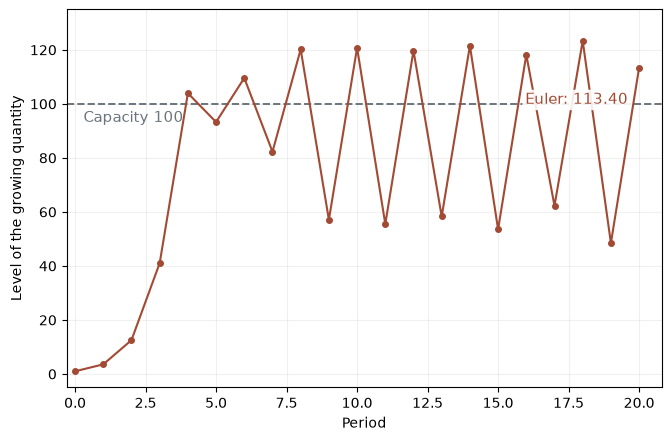

- **Solver:** Euler
- **Step:** 1.0000
- **Final value:** 113.40
- **Highest value reached:** 123.35
- **Final value minus capacity:** 13.40

Euler's first step is 1 + 1.0000 x 2.6 x 1 x (1 - 1/100) = 1 + 1.0000 x 2.574 = 3.5740. Repeating that for 20 steps ends at 113.40 after reaching 123.35, so the final value minus the capacity is 113.40 - 100 = 13.40. That is 13.40 above the capacity, a breach of the capacity bound made by the solver alone (a bound violation, not a loss of conservation).

In [5]:
show(three_solvers(solver='euler', dt=1.0))

**Use the idea.** Before comparing two runs of a model, check that they used the same solver and step.

**Where the conclusion applies.** One growth model, a start of 1, twenty periods, and the chapter's three solvers. The conclusion fails for a model whose rate is nearly constant across a step, where all three agree.

*Constructed example: the chapter's first table, rate 2.6, capacity 100, step 1.0, recomputed with the chapter's integrate function.*

Every setting the interactive reader offers for this demonstration:

In [6]:
sweep(three_solvers, [('solver', ['euler', 'heun', 'rk4']), ('dt', [1.0, 0.0625])])

- **solver = euler, dt = 1.0**: Solver Euler; Step 1.0000; Final value 113.40; Highest value reached 123.35; Final value minus capacity 13.40
- **solver = euler, dt = 0.0625**: Solver Euler; Step 0.0625; Final value 100.00; Highest value reached 100.00; Final value minus capacity 0.00
- **solver = heun, dt = 1.0**: Solver Heun; Step 1.0000; Final value 56.51; Highest value reached 69.50; Final value minus capacity (-43.49)
- **solver = heun, dt = 0.0625**: Solver Heun; Step 0.0625; Final value 100.00; Highest value reached 100.00; Final value minus capacity 0.00
- **solver = rk4, dt = 1.0**: Solver Runge-Kutta 4; Step 1.0000; Final value 99.88; Highest value reached 99.88; Final value minus capacity (-0.12)
- **solver = rk4, dt = 0.0625**: Solver Runge-Kutta 4; Step 0.0625; Final value 100.00; Highest value reached 100.00; Final value minus capacity 0.00

## 2. What Euler assumes about the rate

*Why does Euler overshoot a limit, and how does the step change it?*

The rate is largest when the level is far from the capacity, so the start-of-step rate is too high for the rest of the step. The error grows with the rate and the step, so a smaller step or a gentler rate shrinks it.

    step_refinement(derivative, 1.0, horizon=20, solver="euler"

**Symbols and inputs.** The rate is growth rate x level x (1 - level / 100). Euler reads it once at the start of each step and multiplies by the step. The exact curve is the closed-form logistic.

**Predict first.** At growth rate 2.6, does halving the step from 1.0 to 0.5 remove the overshoot above 100?

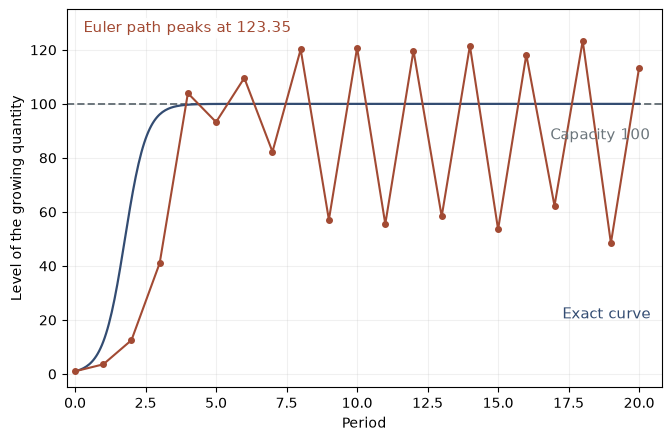

- **Growth rate:** 2.6
- **Step:** 1.00
- **Rate used for the first step:** 2.574
- **Euler value after one step:** 3.5740
- **Exact value at that time:** 11.9716
- **Highest Euler value:** 123.35
- **Final Euler value:** 113.40

Euler reads the rate once at the start of a step: 2.6 x 1 x (1 - 1/100) = 2.574, and assumes it holds for the whole step, so the first step adds 1.00 x 2.574 = 2.5740 to give 3.5740, while the exact curve is 11.9716 at that time. The path breaches the capacity: 123.35 - 100 = 23.35 above it. The final value is 113.40.

In [7]:
show(euler_assumption(dt=1.0, rate=2.6))

**Use the idea.** Choose the step small relative to the fastest change in the model, then confirm by halving it.

**Where the conclusion applies.** Euler only, a start of 1 and twenty periods. At a step of 0.5 the path still peaks at 101.14, above the capacity, so a settled endpoint alone does not clear the step.

*Constructed example: the chapter's logistic with rate and step values chosen for this reader, Euler from the chapter's code, exact curve by the closed form.*

Every setting the interactive reader offers for this demonstration:

In [8]:
sweep(euler_assumption, [('dt', [1.0, 0.5, 0.25]), ('rate', [1.5, 2.6])])

- **dt = 1.0, rate = 1.5**: Growth rate 1.5; Step 1.00; Rate used for the first step 1.485; Euler value after one step 2.4850; Exact value at that time 4.3309; Highest Euler value 100.19; Final Euler value 100.00
- **dt = 1.0, rate = 2.6**: Growth rate 2.6; Step 1.00; Rate used for the first step 2.574; Euler value after one step 3.5740; Exact value at that time 11.9716; Highest Euler value 123.35; Final Euler value 113.40
- **dt = 0.5, rate = 1.5**: Growth rate 1.5; Step 0.50; Rate used for the first step 1.485; Euler value after one step 1.7425; Exact value at that time 2.0936; Highest Euler value 100.00; Final Euler value 100.00
- **dt = 0.5, rate = 2.6**: Growth rate 2.6; Step 0.50; Rate used for the first step 2.574; Euler value after one step 2.2870; Exact value at that time 3.5739; Highest Euler value 101.14; Final Euler value 100.00
- **dt = 0.25, rate = 1.5**: Growth rate 1.5; Step 0.25; Rate used for the first step 1.485; Euler value after one step 1.3712; Exact value at that time 1.4484; Highest Euler value 100.00; Final Euler value 100.00
- **dt = 0.25, rate = 2.6**: Growth rate 2.6; Step 0.25; Rate used for the first step 2.574; Euler value after one step 1.6435; Exact value at that time 1.8982; Highest Euler value 100.00; Final Euler value 100.00

## 3. Sequential update is a different model

*When two stocks exchange a quantity, does the update order change the total?*

Simultaneous update reads both flows from the old state, so what leaves one stock enters the other. Sequential update lets B's flow see A's new value, so the transfer is no longer closed.

    sequential_pair(100.0, 0.0, dt=1.0, k=0.3)
    simultaneous_pair(100.0, 0.0, dt=1.0, k=0.3)

**Symbols and inputs.** A and B are stocks, starting at 100 and 0. k is the fraction of the gap that moves per step. The step is 1, so the flow from B to A is k x (B - A).

**Predict first.** With k = 0.3, how many units vanish if A is written before B's flow is computed?

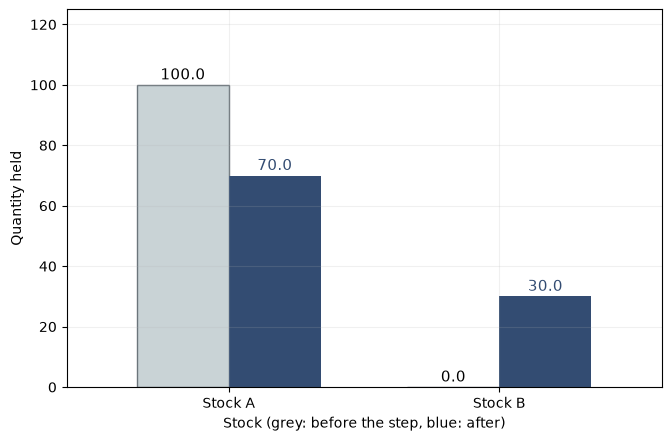

- **Update rule:** simultaneous
- **Stock A after one step:** 70.0
- **Stock B after one step:** 30.0
- **Total after one step:** 100.0
- **Quantity created or lost:** 0.0

Both flows are read at the start: k x (0 - 100) = 0.3 x (-100) = (-30.0) for A, so A = 100 + (-30.0) = 70.0 and B = 0 + 30.0 = 30.0. Total 70.0 + 30.0 = 100.0, nothing created or lost.

In [9]:
show(update_order(k=0.3, order='simultaneous'))

**Use the idea.** Test a runtime with the invariant that a closed transfer conserves its total, not with a trajectory.

**Where the conclusion applies.** A closed two-stock transfer, one step, and k between 0.1 and 0.5. With k = 0 nothing moves and both updates agree.

*Constructed example: the chapter's closed transfer from 100 and 0, with k values chosen for this reader, run through the chapter's two update functions.*

Every setting the interactive reader offers for this demonstration:

In [10]:
sweep(update_order, [('k', [0.1, 0.3, 0.5]), ('order', ['simultaneous', 'sequential'])])

- **k = 0.1, order = simultaneous**: Update rule simultaneous; Stock A after one step 90.0; Stock B after one step 10.0; Total after one step 100.0; Quantity created or lost 0.0
- **k = 0.1, order = sequential**: Update rule sequential; Stock A after one step 90.0; Stock B after one step 9.0; Total after one step 99.0; Quantity created or lost (-1.0)
- **k = 0.3, order = simultaneous**: Update rule simultaneous; Stock A after one step 70.0; Stock B after one step 30.0; Total after one step 100.0; Quantity created or lost 0.0
- **k = 0.3, order = sequential**: Update rule sequential; Stock A after one step 70.0; Stock B after one step 21.0; Total after one step 91.0; Quantity created or lost (-9.0)
- **k = 0.5, order = simultaneous**: Update rule simultaneous; Stock A after one step 50.0; Stock B after one step 50.0; Total after one step 100.0; Quantity created or lost 0.0
- **k = 0.5, order = sequential**: Update rule sequential; Stock A after one step 50.0; Stock B after one step 25.0; Total after one step 75.0; Quantity created or lost (-25.0)

## 4. The refinement test

*Three runs at halved steps: has the answer settled?*

Convergence means the last halving moved the endpoint by less than the tolerance. A sequence that keeps moving by a similar amount at every halving has not settled, however small the tolerance.

    step_refinement(derivative, 1.0, horizon=20, solver="euler"
    converged([50.0, 70.0, 90.0], tolerance=0.1)

**Symbols and inputs.** Each run ends at period 20 for steps 1, 0.5 and 0.25 (or three runs of a made-up sequence). The tolerance is the largest last gap still called converged.

**Predict first.** With a tolerance of 0.1, does the sequence 50, 70, 90 count as converged?

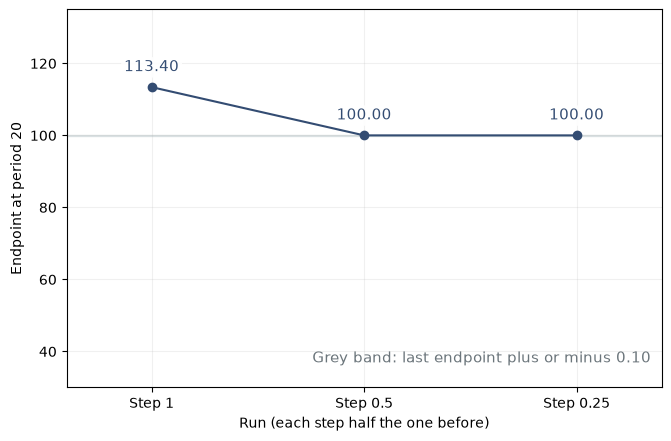

- **Runs:** Euler endpoints at steps 1, 0.5, 0.25
- **First gap:** 13.40
- **Last gap:** 0.00
- **Tolerance:** 0.10
- **Verdict:** converged

First gap |100.00 - 113.40| = 13.40. Last gap |100.00 - 100.00| = 0.00, compared with the tolerance 0.10: 0.00 < 0.10, so the verdict is converged. The last halving moved the endpoint by less than the tolerance, so the sequence is called converged. That is a statement about the endpoint only; the path and the invariants still need checking.

In [11]:
show(refinement(case='euler', tolerance=0.1))

**Use the idea.** Record the three endpoints beside the model so a later reader can judge the step.

**Where the conclusion applies.** Only the last gap is tested, as the chapter's code does. A settled endpoint does not clear the path, and a large tolerance can call a sequence settled that is still moving.

*Constructed example: the chapter's refinement test on its growth model and the sequence 50, 70, 90, run through the chapter's step_refinement and converged functions.*

Every setting the interactive reader offers for this demonstration:

In [12]:
sweep(refinement, [('case', ['euler', 'heun', 'rk4', 'moving']), ('tolerance', [0.1, 25.0])])

- **case = euler, tolerance = 0.1**: Runs Euler endpoints at steps 1, 0.5, 0.25; First gap 13.40; Last gap 0.00; Tolerance 0.10; Verdict converged
- **case = euler, tolerance = 25.0**: Runs Euler endpoints at steps 1, 0.5, 0.25; First gap 13.40; Last gap 0.00; Tolerance 25.00; Verdict converged
- **case = heun, tolerance = 0.1**: Runs Heun endpoints at steps 1, 0.5, 0.25; First gap 43.49; Last gap 0.00; Tolerance 0.10; Verdict converged
- **case = heun, tolerance = 25.0**: Runs Heun endpoints at steps 1, 0.5, 0.25; First gap 43.49; Last gap 0.00; Tolerance 25.00; Verdict converged
- **case = rk4, tolerance = 0.1**: Runs Runge-Kutta 4 endpoints at steps 1, 0.5, 0.25; First gap 0.12; Last gap 0.00; Tolerance 0.10; Verdict converged
- **case = rk4, tolerance = 25.0**: Runs Runge-Kutta 4 endpoints at steps 1, 0.5, 0.25; First gap 0.12; Last gap 0.00; Tolerance 25.00; Verdict converged
- **case = moving, tolerance = 0.1**: Runs the endpoints 50, 70, 90 from the chapter's example; First gap 20.00; Last gap 20.00; Tolerance 0.10; Verdict not converged
- **case = moving, tolerance = 25.0**: Runs the endpoints 50, 70, 90 from the chapter's example; First gap 20.00; Last gap 20.00; Tolerance 25.00; Verdict converged

## Exercises

Try each before opening the answer. The settings above let you check the numbers.

### Exercise 1

At a step of 0.0625, how far from 100 do the three solvers end, to two decimals?

<details><summary>Answer</summary>

All three end at 100.00, so the three answers at a step of 1.0 came from the step, not the model.

</details>

### Exercise 2

At growth rate 1.5 and a step of 0.5, does Euler ever exceed 100?

<details><summary>Answer</summary>

No. The largest value is 100.00, because the rate times the step, 1.5 x 0.5 = 0.75, is small.

</details>

### Exercise 3

With k = 0.5 and sequential update, what is the total after one step?

<details><summary>Answer</summary>

A = 100 + 0.5 x (0 - 100) = 50, B = 0 + 0.5 x (50 - 0) = 25, total 75, so 25 units vanish.

</details>

---

From *Systems Thinking with AI* by Jason Karpeles. Copyright Jason Karpeles. All rights reserved.

Interactive companion: https://karpeles.com/companions/systems-thinking-with-ai/